In [1]:
import pandas as pd
df = pd.read_csv("netflix_titles.csv")
df.head()



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df['type'].value_counts()


type
Movie      6131
TV Show    2676
Name: count, dtype: int64

<Axes: title={'center': 'count of Movies vs TV Shows'}, xlabel='type'>

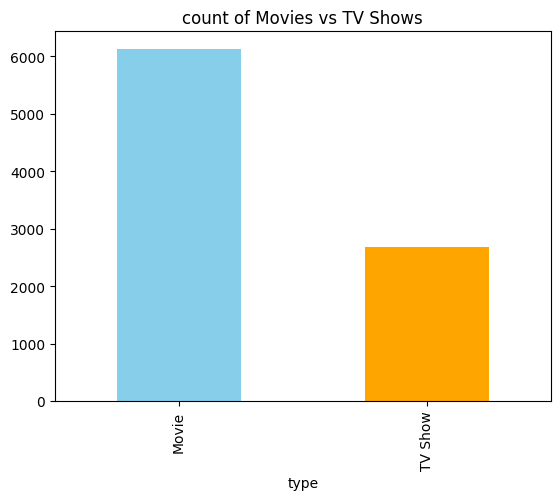

In [3]:
df['type'].value_counts().plot(kind='bar', title='count of Movies vs TV Shows', color=['skyblue', 'orange'])

<Axes: title={'center': 'top 10 Countries with netflix content'}, ylabel='country'>

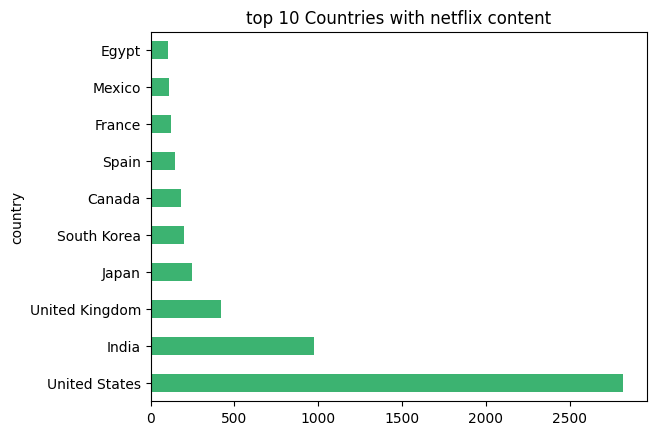

In [5]:
df['country'].value_counts().head(10).plot(kind='barh', title='top 10 Countries with netflix content', color='mediumseagreen')

In [6]:
df['country'].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [10]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


In [11]:
df['year_added'] = df['date_added'].dt.year


<Axes: title={'center': 'Netlix Titles Added over the Years'}, xlabel='year_added'>

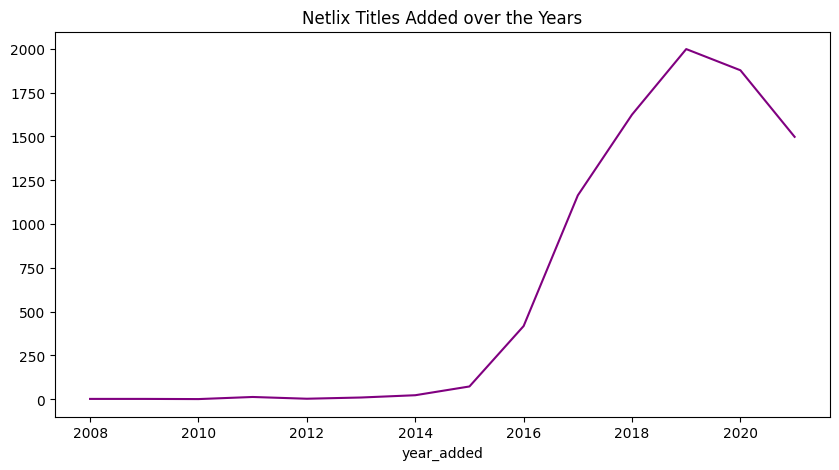

In [12]:
df['year_added'].value_counts().sort_index().plot(kind='line', figsize=(10, 5), title='Netlix Titles Added over the Years', color='purple')

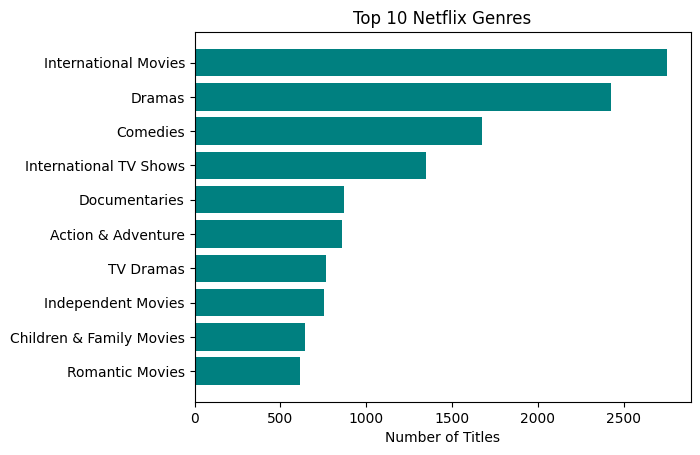

In [17]:
# Split all genres by comma and count each one
from collections import Counter

genre_series = df['listed_in'].dropna().apply(lambda x: [i.strip() for i in x.split(',')])
genre_flat = [genre for sublist in genre_series for genre in sublist]

genre_counts = Counter(genre_flat)
top_genres = dict(genre_counts.most_common(10))

# Plot it
import matplotlib.pyplot as plt

plt.barh(list(top_genres.keys()), list(top_genres.values()), color='teal')
plt.title('Top 10 Netflix Genres')
plt.xlabel('Number of Titles')
plt.gca().invert_yaxis()
plt.show()


In [18]:
#top 10 directors
top_directors = df['director'].dropna().value_counts().head(10)

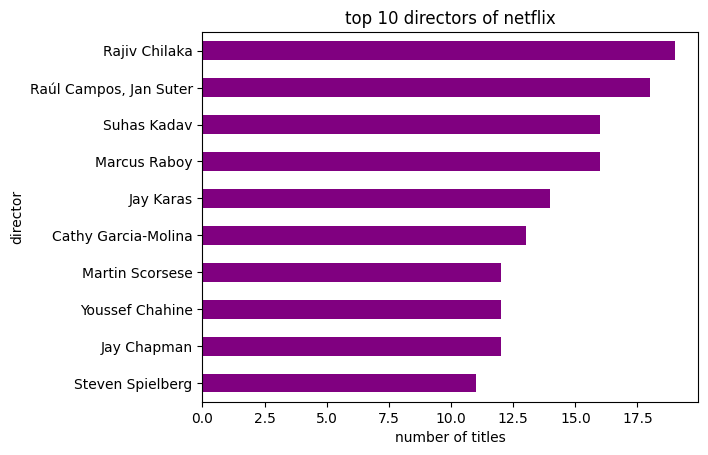

In [19]:
top_directors.plot(kind='barh', title='top 10 directors of netflix', color='purple')
plt.xlabel('number of titles')
plt.gca().invert_yaxis()

In [20]:
plt.show()

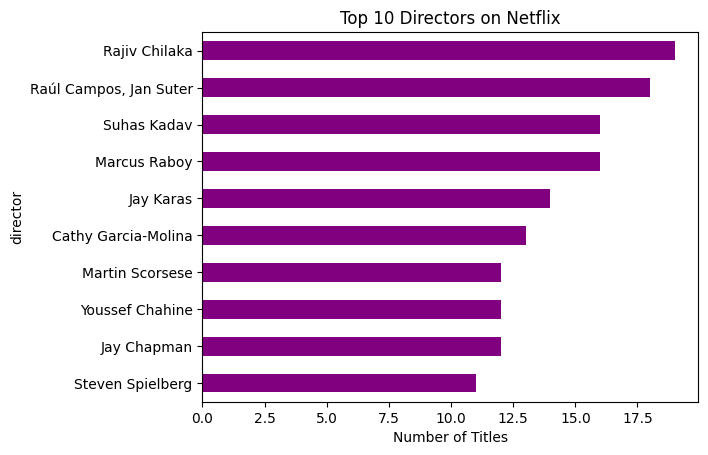

In [21]:
top_directors = df['director'].dropna().value_counts().head(10)

top_directors.plot(kind='barh', title='Top 10 Directors on Netflix', color='purple')
plt.xlabel('Number of Titles')
plt.gca().invert_yaxis()
plt.show()



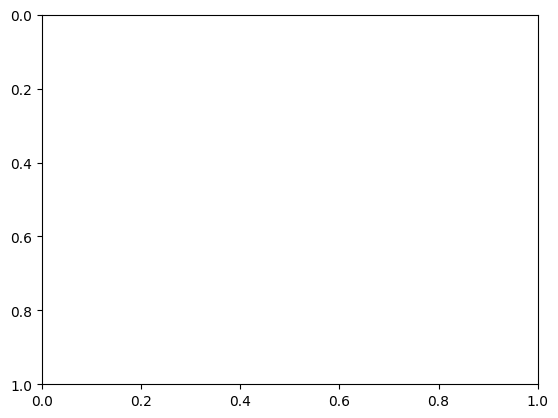

In [23]:
cast_series = df['cast'].dropna().apply(lambda x: [i.strip() for i in x.split(',')])
all_actors = [actor for sublist in cast_series for actor in sublist]
plt.gca().invert_yaxis()

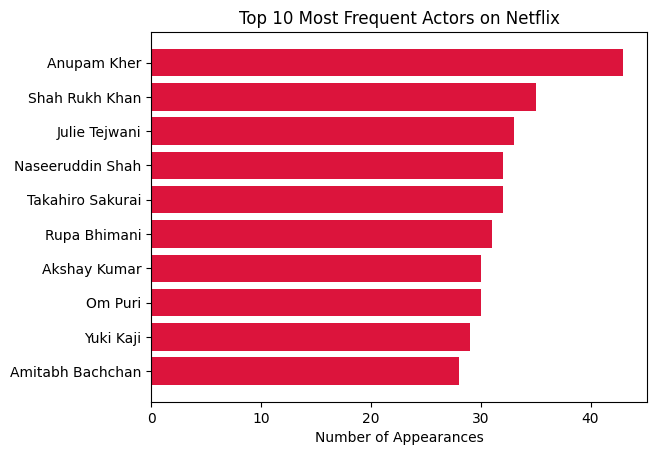

In [24]:
cast_series = df['cast'].dropna().apply(lambda x: [i.strip() for i in x.split(',')])
all_actors = [actor for sublist in cast_series for actor in sublist]

from collections import Counter
actor_counts = Counter(all_actors)
top_actors = dict(actor_counts.most_common(10))

plt.barh(list(top_actors.keys()), list(top_actors.values()), color='crimson')
plt.title('Top 10 Most Frequent Actors on Netflix')
plt.xlabel('Number of Appearances')
plt.gca().invert_yaxis()
plt.show()



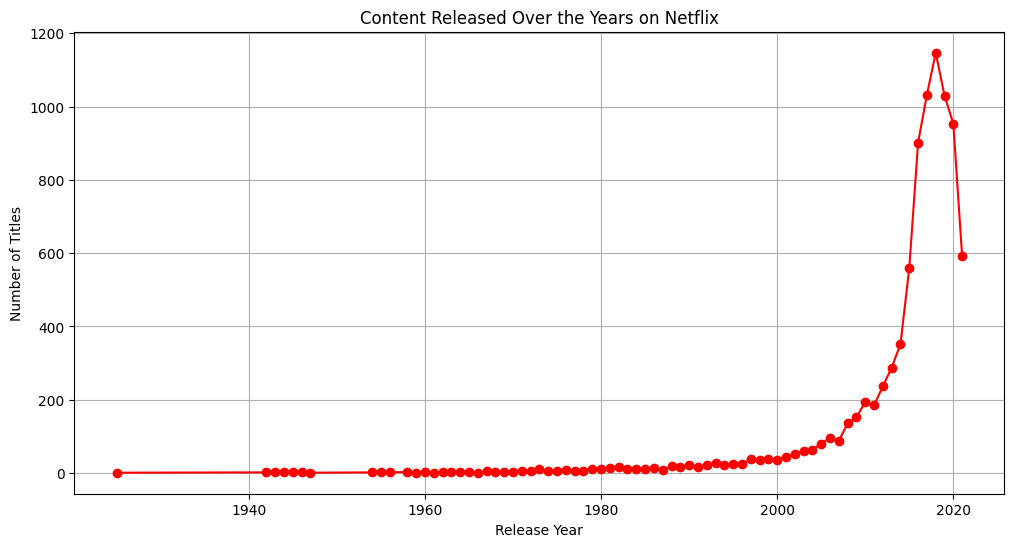

In [25]:
# Extract release year from 'release_year' column
release_counts = df['release_year'].value_counts().sort_index()

# Plot the trend
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(release_counts.index, release_counts.values, marker='o', color='red')
plt.title('Content Released Over the Years on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()


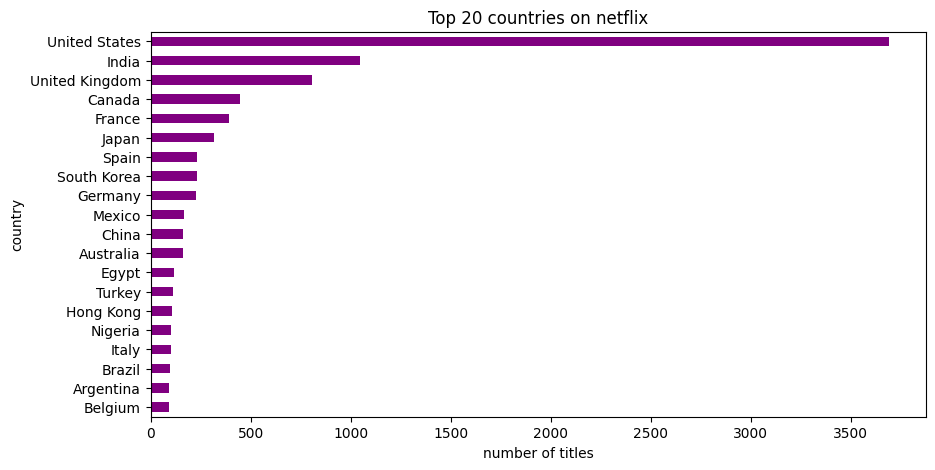

In [28]:
country = df['country'].dropna().apply(lambda x: [i.strip() for i in x.split(',')])
all_countries = [country for sublist in country for country in sublist]

import pandas as pd
country_counts = pd.Series(all_countries).value_counts().head(20)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
country_counts.plot(kind='barh', color='purple')
plt.title('Top 20 countries on netflix')
plt.xlabel('number of titles')
plt.ylabel('country')
plt.gca().invert_yaxis()
plt.show()



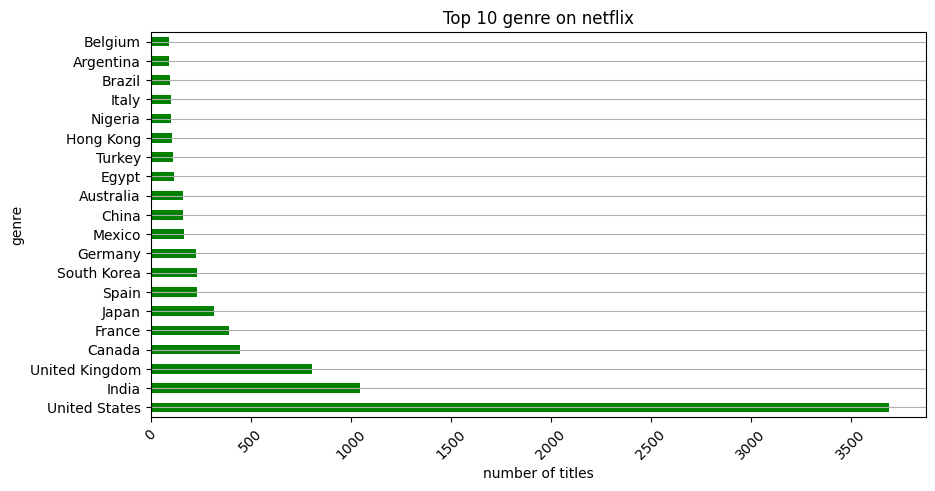

In [34]:
genre_series = df['listed_in'].dropna().apply(lambda x: [i.strip() for i in x.split(',')])
all_genres = [genre for sublist in genre_series for genre in sublist]

import pandas as pd
genre_counts = pd.Series(all_genres).value_counts().head(10)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
country_counts.plot(kind='barh', color='green')
plt.title('Top 10 genre on netflix')
plt.xlabel('number of titles')
plt.ylabel('genre')

plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()



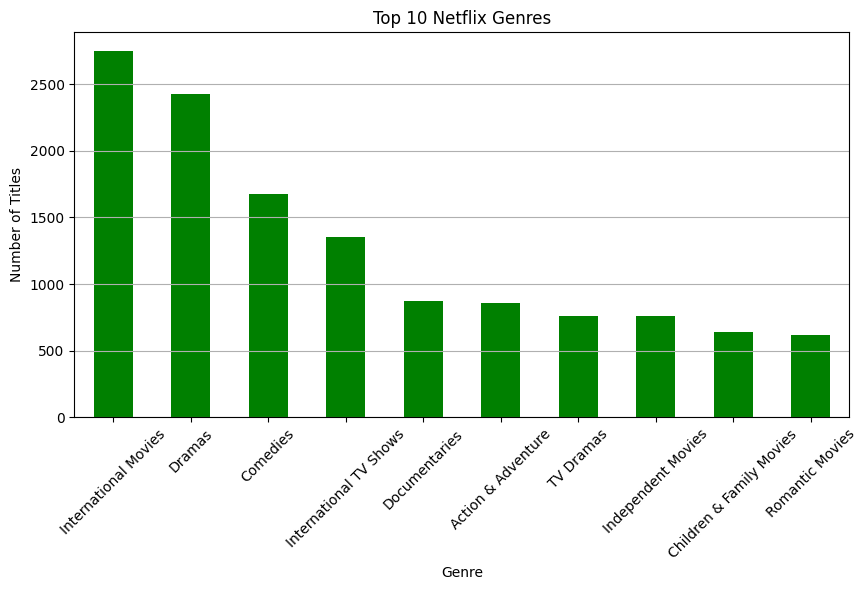

In [35]:
genre_series = df['listed_in'].dropna().apply(lambda x: [i.strip() for i in x.split(',')])
all_genres = [genre for sublist in genre_series for genre in sublist]

import pandas as pd
genre_counts = pd.Series(all_genres).value_counts().head(10)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
genre_counts.plot(kind='bar', color='green')
plt.title('Top 10 Netflix Genres')
plt.ylabel('Number of Titles')
plt.xlabel('Genre')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


In [36]:
from wordcloud import WordCloud, STOPWORDS

# Join all titles into a single string
title_text = " ".join(df['title'].dropna().tolist())

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400,
                      background_color='black',
                      stopwords=STOPWORDS,
                      colormap='Set2').generate(title_text)

# Plot it
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Netflix Titles', fontsize=20)
plt.show()


ModuleNotFoundError: No module named 'wordcloud'

In [37]:
!pip install wordcloud



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


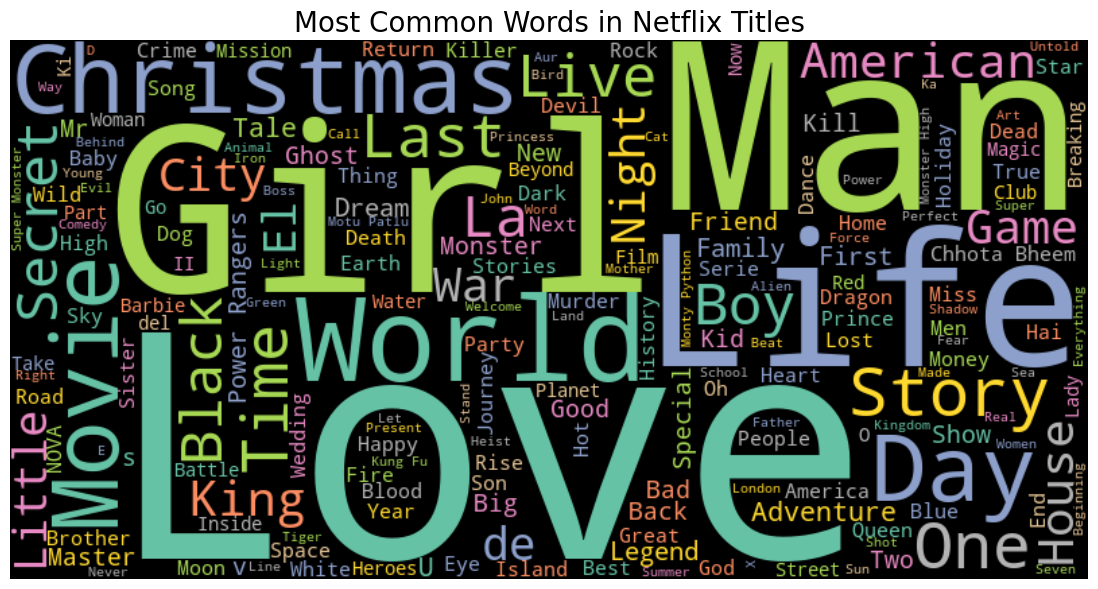

In [40]:
 from wordcloud import WordCloud, STOPWORDS

# Join all titles into a single string
title_text = " ".join(df['title'].dropna().tolist())

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400,
                      background_color='black',
                      stopwords=STOPWORDS,
                      colormap='Set2').generate(title_text)

# Plot it
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Netflix Titles', fontsize=20)
plt.show()



In [41]:
from collections import Counter

# Combine all titles into one big string
all_titles = ' '.join(df['title'].dropna()).lower()

# Split into words
words = all_titles.split()

# Count word frequencies
word_counts = Counter(words)

# Show top 10 most common words
print(word_counts.most_common(10))


[('the', 2227), ('of', 708), ('a', 352), ('in', 284), ('and', 234), ('to', 199), ('&', 179), ('love', 151), ('my', 144), ('2', 104)]


In [42]:
stopwords = {'the', 'and', 'of', 'a', 'in', 'to', 'on', 'at', 'with', 'for'}
filtered_words = [word for word in words if word not in stopwords]
word_counts = Counter(filtered_words)
print(word_counts.most_common(10))


[('&', 179), ('love', 151), ('my', 144), ('2', 104), ('i', 96), ('you', 79), ('man', 77), ('christmas', 77), ('story', 73), ('life', 71)]


In [43]:
from collections import Counter

all_titles = ' '.join(df['title'].dropna()).lower()
words = all_titles.split()

stopwords = {'the', 'and', 'of', 'a', 'in', 'to', 'on', 'at', 'with', 'for'}
filtered_words = [word for word in words if word not in stopwords]

word_counts = Counter(filtered_words)
common_words = word_counts.most_common(10)  # Top 10


In [44]:
words, counts = zip(*common_words)


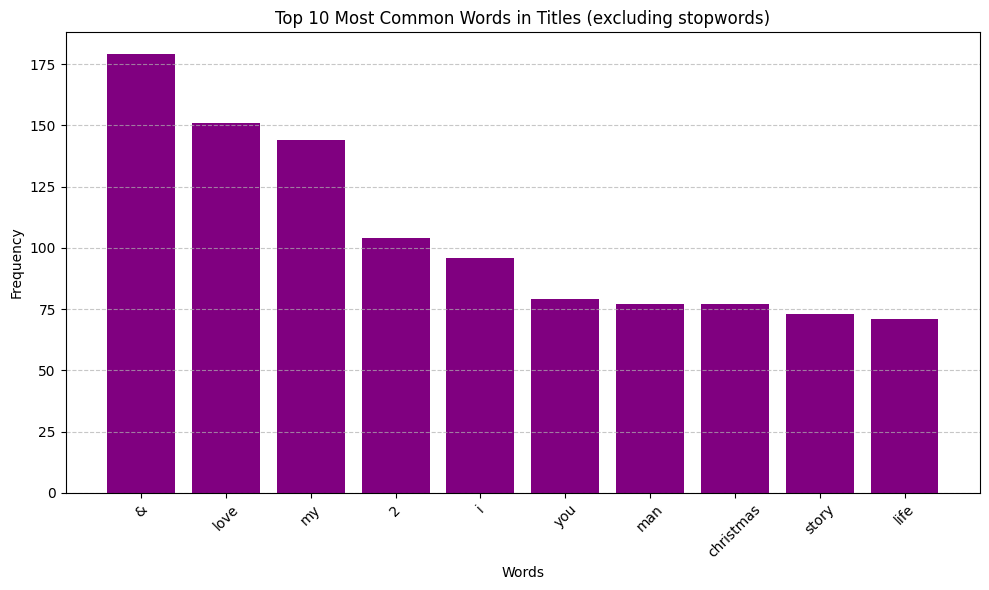

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(words, counts, color='purple')
plt.title('Top 10 Most Common Words in Titles (excluding stopwords)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


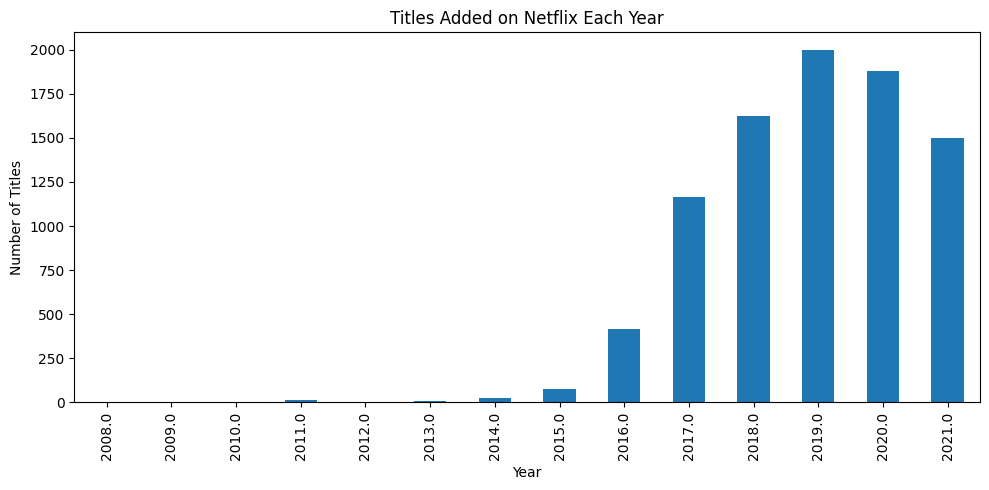

In [46]:
#time trend

# Convert 'date_added' to datetime
df['date_added'] = pd.to_datetime(df['date_added'])

# Extract year from 'date_added'
df['year_added'] = df['date_added'].dt.year

# Drop rows where 'year_added' is NaN
df = df.dropna(subset=['year_added'])

# Plot titles added per year
plt.figure(figsize=(10, 5))
df['year_added'].value_counts().sort_index().plot(kind='bar')
plt.title('Titles Added on Netflix Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()


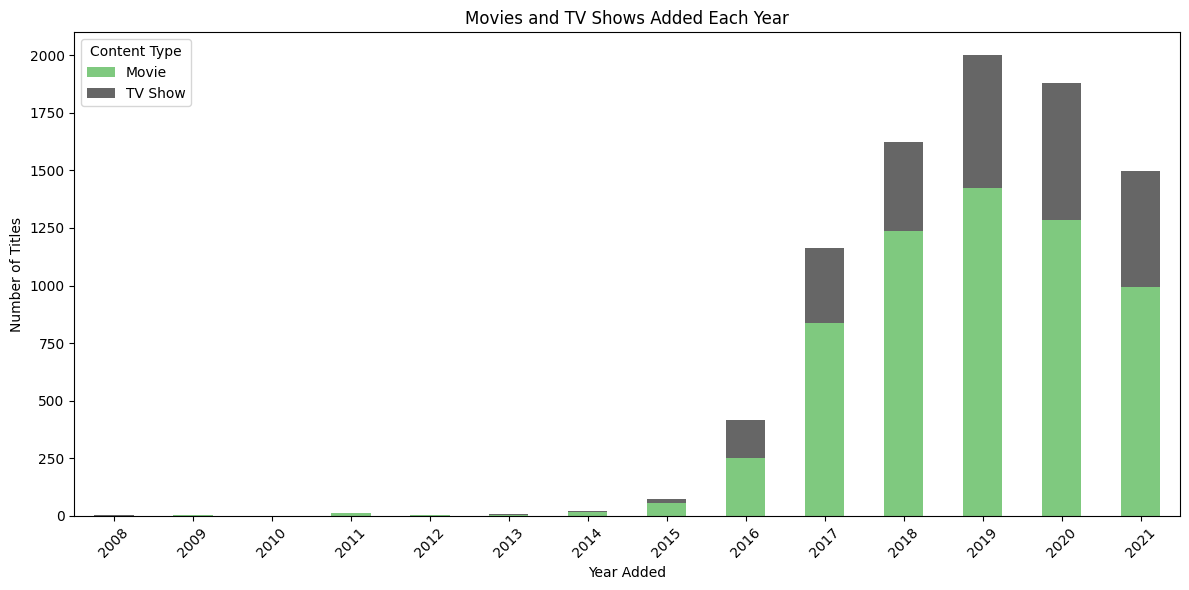

In [47]:
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

content_by_year = df.groupby(['year_added', 'type']).size().unstack().fillna(0)

content_by_year.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Accent')

plt.title('Movies and TV Shows Added Each Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.legend(title='Content Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





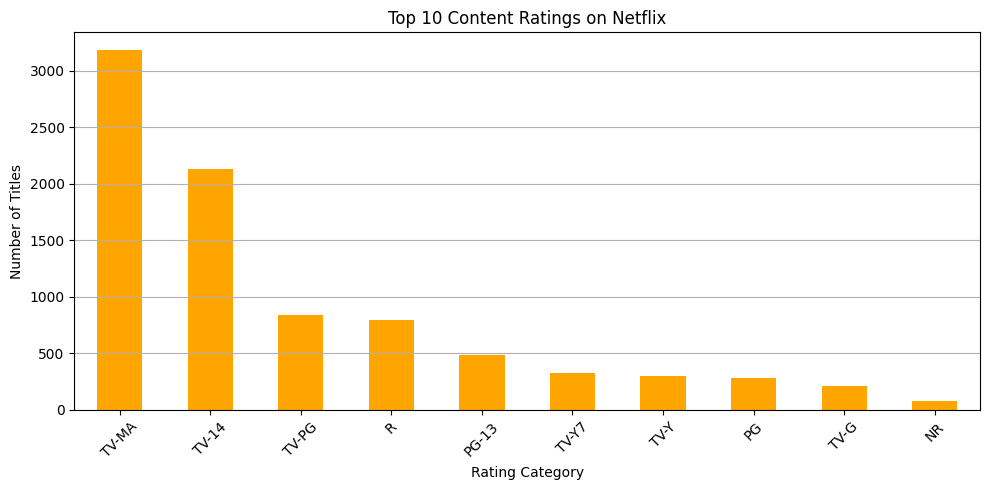

In [48]:
rating_counts = df['rating'].value_counts().head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
rating_counts.plot(kind='bar', color='orange')

plt.title('Top 10 Content Ratings on Netflix')
plt.xlabel('Rating Category')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
